In [19]:
# Import libraries
import subprocess
import json
import time
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import subprocess
import time
import matplotlib.pyplot as plt
import numpy as np

def run_benchmark(num_runs=3):
    """Run analysis_job.py num_runs times"""
    times = []
    
    for run in range(num_runs):
        print(f"\n  Run {run+1}/{num_runs}...", end=" ", flush=True)
        
        try:
            cmd = """
            spark-submit --master spark://192.168.2.25:7077 \
              --executor-memory 2500M \
              --driver-memory 2G \
              --executor-cores 2 \
              --conf spark.sql.shuffle.partitions=48 \
              ~/DE_1_project_group_12/src/analysis_job.py
            """
            
            start = time.time()
            result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=1000)
            elapsed = time.time() - start
            
            times.append(elapsed)
            print(f"{elapsed:.2f}s")
            
        except Exception as e:
            print(f"Error: {e}")
    
    return times

print("Function defined")

Function defined


In [3]:
print("\n" + "="*60)
print("TEST A: 1 WORKER")
print("="*60)

# Stop Worker 2 and 3 in the terminal first
# ssh ubuntu@192.168.2.129 ~/spark-3.5.1-bin-hadoop3/sbin/stop-worker.sh spark://192.168.2.25:7077
# ssh ubuntu@192.168.2.8 ~/spark-3.5.1-bin-hadoop3/sbin/stop-worker.sh spark://192.168.2.25:7077

print("Running 3 iterations with 1 Worker...")
results_1worker = run_benchmark(num_runs=3)

avg_1 = np.mean(results_1worker)
std_1 = np.std(results_1worker)

print(f"\n1 Worker Results:")
print(f"  Average: {avg_1:.2f}s")
print(f"  Std Dev: {std_1:.2f}s")
print(f"  Times: {[f'{t:.2f}s' for t in results_1worker]}")


TEST A: 1 WORKER
Running 3 iterations with 1 Worker...

  Run 1/3... 

KeyboardInterrupt: 

In [24]:
print("\n" + "="*60)
print("TEST B: 2 WORKERS")
print("="*60)

# Start worker 2 in the terminal first.
# ssh ubuntu@192.168.2.129 ~/spark-3.5.1-bin-hadoop3/sbin/start-worker.sh spark://192.168.2.25:7077
# Verify that 2 workers is active in Spark UI (localhost:8080)

print("Running 3 iterations with 2 Workers...")
results_2workers = run_benchmark(num_runs=3)

avg_2 = np.mean(results_2workers)
std_2 = np.std(results_2workers)

print(f"\n2 Workers Results:")
print(f"  Average: {avg_2:.2f}s")
print(f"  Std Dev: {std_2:.2f}s")
print(f"  Times: {[f'{t:.2f}s' for t in results_2workers]}")


TEST B: 2 WORKERS
Running 3 iterations with 2 Workers...

  Run 1/3... 169.68s

  Run 2/3... 295.08s

  Run 3/3... 296.59s

2 Workers Results:
  Average: 253.79s
  Std Dev: 59.47s
  Times: ['169.68s', '295.08s', '296.59s']


In [26]:
print("\n" + "="*60)
print("TEST C: 3 WORKERS")
print("="*60)

# Start worker 3 in the terminal first
# ssh ubuntu@192.168.2.8 ~/spark-3.5.1-bin-hadoop3/sbin/start-worker.sh spark://192.168.2.25:7077
# Verify that 3 workers is active in Spark UI (localhost:8080)

print("Running 3 iterations with 3 Workers...")
results_3workers = run_benchmark(num_runs=3)

avg_3 = np.mean(results_3workers)
std_3 = np.std(results_3workers)

print(f"\n 3 Workers Results:")
print(f"  Average: {avg_3:.2f}s")
print(f"  Std Dev: {std_3:.2f}s")
print(f"  Times: {[f'{t:.2f}s' for t in results_3workers]}")


TEST C: 3 WORKERS
Running 3 iterations with 3 Workers...

  Run 1/3... 213.90s

  Run 2/3... 212.51s

  Run 3/3... 224.70s

 3 Workers Results:
  Average: 217.04s
  Std Dev: 5.45s
  Times: ['213.90s', '212.51s', '224.70s']


In [27]:
print("\n" + "="*60)
print("SPEEDUP ANALYSIS")
print("="*60)

worker_counts = [1, 2, 3]
avg_times = [avg_1, avg_2, avg_3]
std_devs = [std_1, std_2, std_3]

baseline = avg_1
speedups = [baseline / t for t in avg_times]
ideal_speedup = worker_counts

print("\nResults Summary:")
print("-" * 60)
for w, t, s in zip(worker_counts, avg_times, speedups):
    ideal = w
    efficiency = (s / ideal) * 100
    print(f"{w} Worker(s): {s:.2f}x speedup | Efficiency: {efficiency:.1f}%")


SPEEDUP ANALYSIS

Results Summary:
------------------------------------------------------------
1 Worker(s): 1.00x speedup | Efficiency: 100.0%
2 Worker(s): 1.31x speedup | Efficiency: 65.7%
3 Worker(s): 1.54x speedup | Efficiency: 51.3%


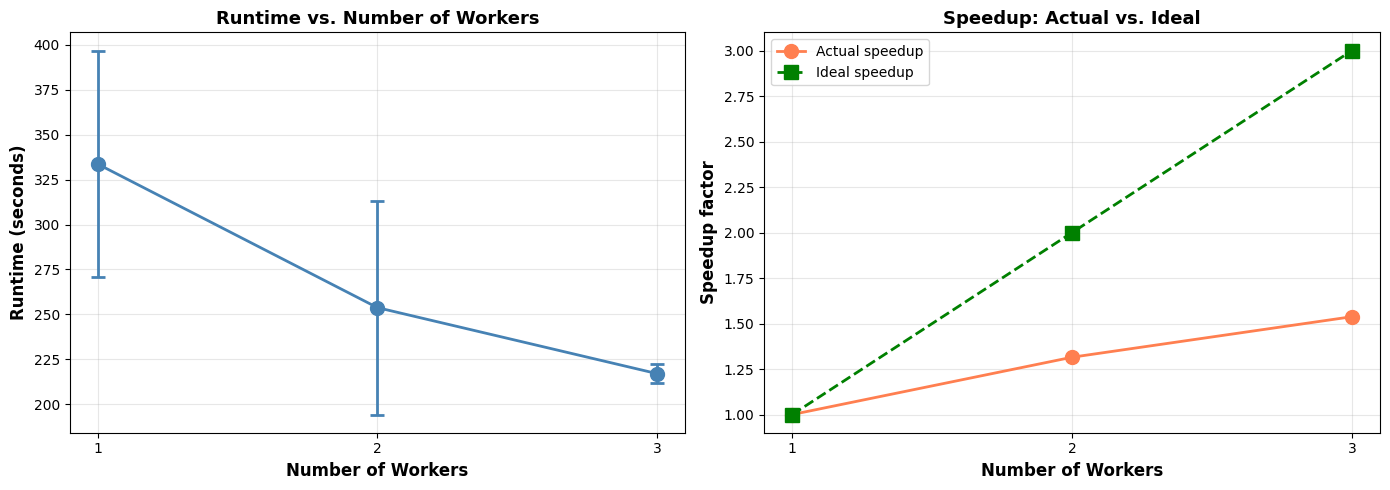

The graphs are saves as benchmark_results_reddit_data.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Runtime vs Workers
axes[0].errorbar(worker_counts, avg_times, yerr=std_devs,
                 marker='o', markersize=10, capsize=5, capthick=2,
                 linestyle='-', linewidth=2, color='steelblue')
axes[0].set_xlabel('Number of Workers', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Runtime vs. Number of Workers', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(worker_counts)

# Plot 2: Speedup
axes[1].plot(worker_counts, speedups, marker='o', markersize=10,
             linestyle='-', linewidth=2, color='coral', label='Actual speedup')
axes[1].plot(worker_counts, ideal_speedup, marker='s', markersize=10,
             linestyle='--', linewidth=2, color='green', label='Ideal speedup')
axes[1].set_xlabel('Number of Workers', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Speedup factor', fontsize=12, fontweight='bold')
axes[1].set_title('Speedup: Actual vs. Ideal', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(worker_counts)

plt.tight_layout()
plt.savefig('benchmark_results_1_core.png', dpi=300, bbox_inches='tight')
plt.show()

print("The graphs are saves as benchmark_results_1_core.png")